<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/Comparative_Analysis_of_Machine_Learning_Models_for_Short_Term_Electricity_Demand_Forecasting_in_Bangladesh_A_SHAP_Enabled_Interpretability_Study_Using_Hourly_PGCB_Data_(2015%E2%80%932025).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install pandas numpy scikit-learn xgboost lightgbm catboost shap matplotlib seaborn plotly optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 41.3 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# For ML
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import optuna

# Models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Dataset/PGCB_date_power_demand.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (92650, 15)
Columns: ['datetime', 'generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc', 'india_tripura', 'india_adani', 'nepal', 'remarks']


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN


In [9]:
# Convert datetime
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

# Handle missing values
df['solar'] = df['solar'].fillna(0)
df['wind'] = df['wind'].fillna(0)
df['nepal'] = df['nepal'].fillna(0)
df['india_adani'] = df['india_adani'].fillna(0)

# Fill other NaNs with 0
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

print("Data cleaned!")
df.info()

Data cleaned!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              92650 non-null  datetime64[ns]
 1   generation_mw         92650 non-null  float64       
 2   demand_mw             92650 non-null  int64         
 3   load_shedding         92650 non-null  int64         
 4   gas                   92650 non-null  int64         
 5   liquid_fuel           92650 non-null  int64         
 6   coal                  92650 non-null  int64         
 7   hydro                 92650 non-null  int64         
 8   solar                 92650 non-null  float64       
 9   wind                  92650 non-null  float64       
 10  india_bheramara_hvdc  92650 non-null  int64         
 11  india_tripura         92650 non-null  int64         
 12  india_adani           92650 non-null  float64       
 13  ne

In [10]:
def create_features(df):
    df = df.copy()

    # Temporal Features
    df['hour'] = df['datetime'].dt.hour
    df['dayofweek'] = df['datetime'].dt.dayofweek
    df['month'] = df['datetime'].dt.month
    df['year'] = df['datetime'].dt.year
    df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)

    # Peak flags
    df['is_evening_peak'] = df['remarks'].str.contains('Evening_Peak', na=False).astype(int)
    df['is_day_peak'] = df['remarks'].str.contains('Day_Peak', na=False).astype(int)

    # Lagged Features
    for lag in [1, 2, 3, 6, 12, 24]:
        df[f'demand_lag_{lag}'] = df['demand_mw'].shift(lag)

    # Rolling Statistics
    df['demand_roll_mean_24'] = df['demand_mw'].rolling(window=24).mean()
    df['demand_roll_max_24'] = df['demand_mw'].rolling(window=24).max()

    # Renewable Share
    df['total_renewable'] = df['hydro'] + df['solar'] + df['wind']
    df['renewable_ratio'] = df['total_renewable'] / (df['generation_mw'] + 1)

    # Import Share
    df['total_import'] = (df['india_bheramara_hvdc'] + df['india_tripura'] +
                         df['india_adani'] + df['nepal'])

    return df

df = create_features(df)
df = df.dropna().reset_index(drop=True)  # Drop initial NaNs from lags
print("Feature engineering completed!")

Feature engineering completed!


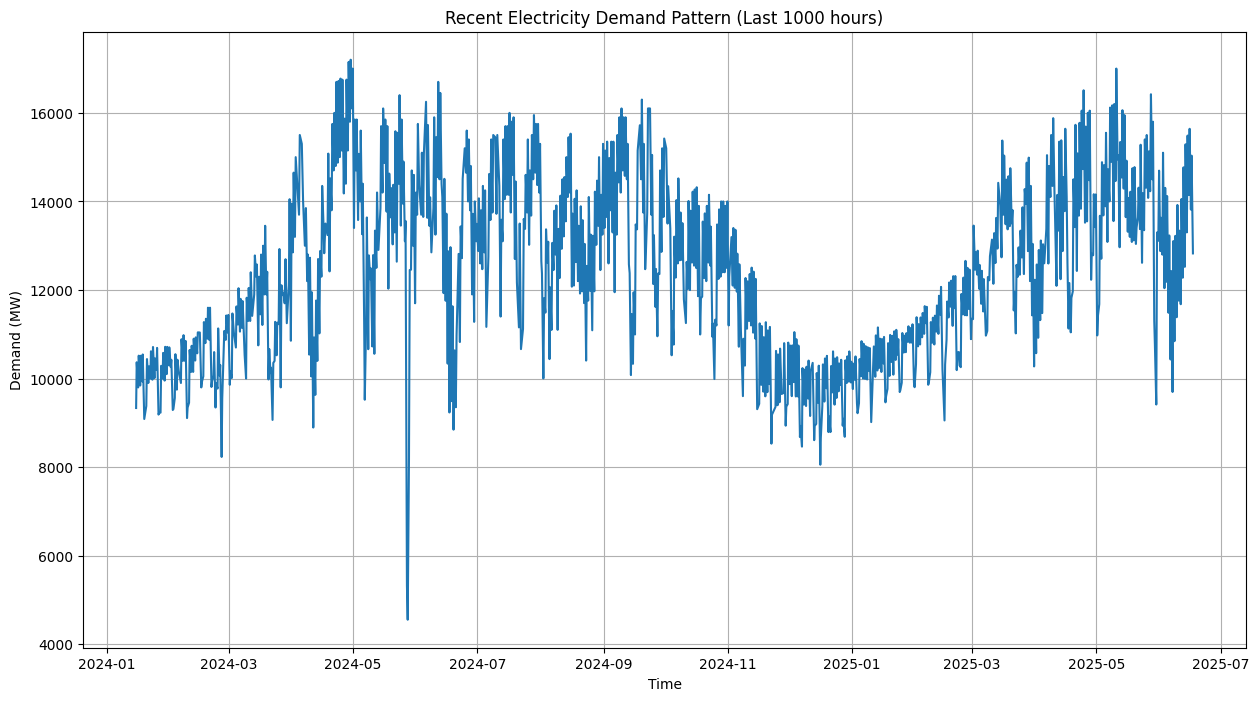

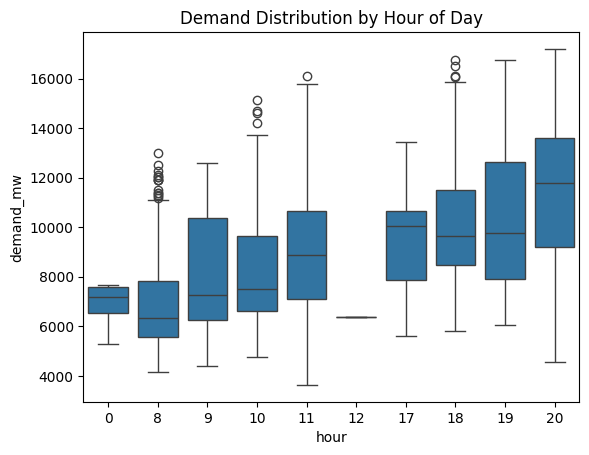

Average Load Shedding: 77.55193992490614


In [11]:
plt.figure(figsize=(15, 8))
plt.plot(df['datetime'].iloc[-1000:], df['demand_mw'].iloc[-1000:])
plt.title('Recent Electricity Demand Pattern (Last 1000 hours)')
plt.xlabel('Time')
plt.ylabel('Demand (MW)')
plt.grid(True)
plt.show()

# Demand by Hour
sns.boxplot(x='hour', y='demand_mw', data=df)
plt.title('Demand Distribution by Hour of Day')
plt.show()

print("Average Load Shedding:", df['load_shedding'].mean())

In [12]:
# Use last 20% as test set
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

print(f"Train: {len(train)}, Test: {len(test)}")

Train: 5113, Test: 1279


In [13]:
target = 'demand_mw'
features = ['hour', 'dayofweek', 'month', 'is_weekend', 'is_evening_peak', 'is_day_peak',
            'demand_lag_1', 'demand_lag_2', 'demand_lag_24', 'demand_roll_mean_24',
            'renewable_ratio', 'total_import', 'gas', 'coal', 'solar']

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1),
    'CatBoost': CatBoostRegressor(iterations=300, learning_rate=0.05, verbose=0, random_state=42)
}

results = {}

In [14]:
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape = np.mean(np.abs((y_test - pred) / y_test)) * 100

    results[name] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}
    print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")

# Results Table
results_df = pd.DataFrame(results).T
print("\n=== MODEL COMPARISON ===")
print(results_df.round(2))

Training LinearRegression...
LinearRegression -> MAE: 354.23, RMSE: 559.25, MAPE: 2.99%
Training RandomForest...
RandomForest -> MAE: 238.77, RMSE: 365.56, MAPE: 2.05%
Training XGBoost...
XGBoost -> MAE: 237.99, RMSE: 363.55, MAPE: 1.97%
Training LightGBM...
LightGBM -> MAE: 240.86, RMSE: 379.07, MAPE: 1.97%
Training CatBoost...
CatBoost -> MAE: 272.14, RMSE: 400.16, MAPE: 2.22%

=== MODEL COMPARISON ===
                     MAE    RMSE  MAPE
LinearRegression  354.23  559.25  2.99
RandomForest      238.77  365.56  2.05
XGBoost           237.99  363.55  1.97
LightGBM          240.86  379.07  1.97
CatBoost          272.14  400.16  2.22


In [15]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
    }
    model = XGBRegressor(**params, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return mean_absolute_error(y_test, pred)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)
print("Best params:", study.best_params)

[I 2026-05-24 14:01:37,703] A new study created in memory with name: no-name-b4345865-e5d5-41e1-a593-41d471232775
[I 2026-05-24 14:01:37,928] Trial 0 finished with value: 235.07545471191406 and parameters: {'n_estimators': 119, 'learning_rate': 0.07308905014305872, 'max_depth': 5}. Best is trial 0 with value: 235.07545471191406.
[I 2026-05-24 14:01:39,442] Trial 1 finished with value: 258.6903381347656 and parameters: {'n_estimators': 411, 'learning_rate': 0.10019943449941252, 'max_depth': 7}. Best is trial 0 with value: 235.07545471191406.
[I 2026-05-24 14:01:40,577] Trial 2 finished with value: 251.86822509765625 and parameters: {'n_estimators': 195, 'learning_rate': 0.27491172491108296, 'max_depth': 8}. Best is trial 0 with value: 235.07545471191406.
[I 2026-05-24 14:01:41,617] Trial 3 finished with value: 248.6314697265625 and parameters: {'n_estimators': 279, 'learning_rate': 0.15656387962884472, 'max_depth': 7}. Best is trial 0 with value: 235.07545471191406.
[I 2026-05-24 14:01:

Best params: {'n_estimators': 195, 'learning_rate': 0.06889125200972658, 'max_depth': 3}


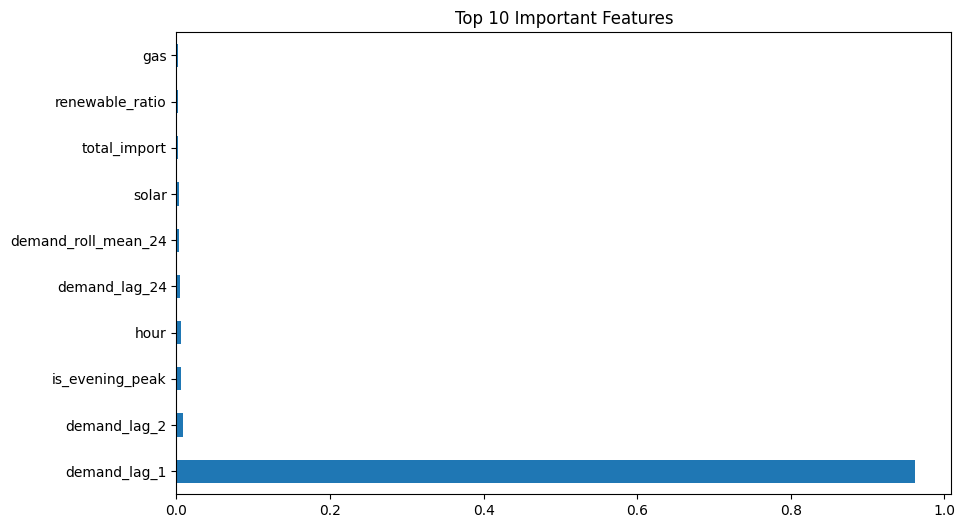

In [16]:
best_model = models['XGBoost']  # or CatBoost
importances = pd.Series(best_model.feature_importances_, index=features)
importances.sort_values(ascending=False).head(10).plot(kind='barh', figsize=(10,6))
plt.title('Top 10 Important Features')
plt.show()

In [17]:
!pip install shap -q

In [18]:
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("SHAP and plotting libraries ready!")

SHAP and plotting libraries ready!


In [19]:
# Using XGBoost as it's fast and SHAP works well with it
from xgboost import XGBRegressor

best_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

best_model.fit(X_train, y_train)

print("Best model trained for SHAP analysis")

Best model trained for SHAP analysis


In [20]:
# Create SHAP Explainer
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values on test set (use subset for speed if dataset is large)
X_test_sample = X_test.iloc[-500:]  # Last 500 samples for faster computation

shap_values = explainer.shap_values(X_test_sample)

print("SHAP values computed!")

SHAP values computed!


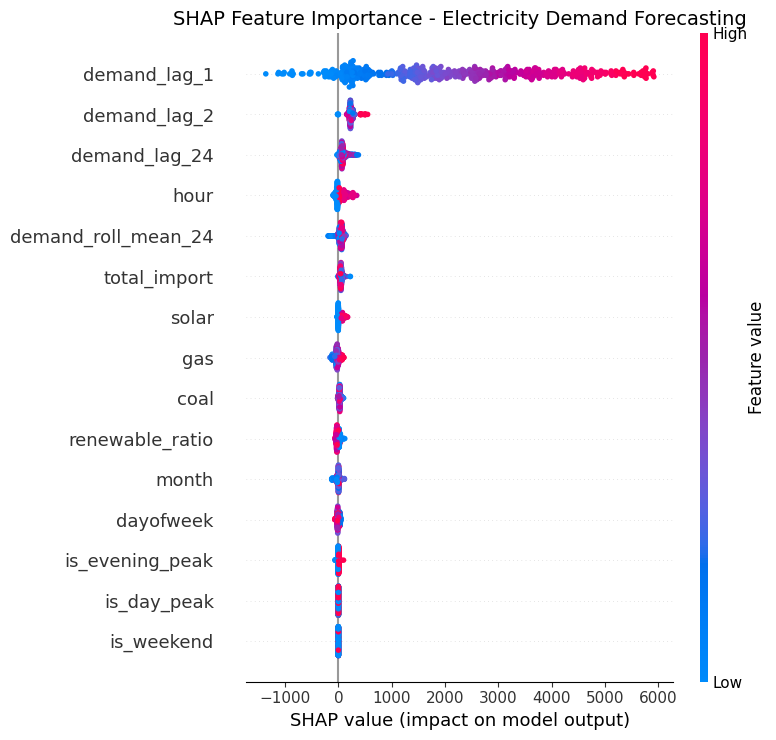

In [21]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="dot", show=False)
plt.title("SHAP Feature Importance - Electricity Demand Forecasting", fontsize=14)
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

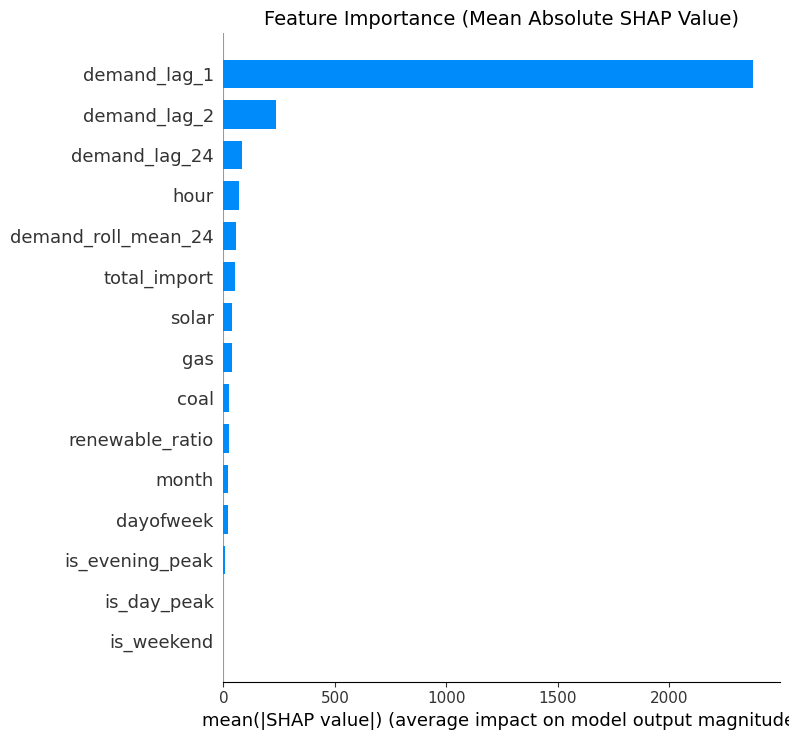

In [22]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title("Feature Importance (Mean Absolute SHAP Value)", fontsize=14)
plt.tight_layout()
plt.savefig('shap_bar_plot.png', dpi=300, bbox_inches='tight')
plt.show()

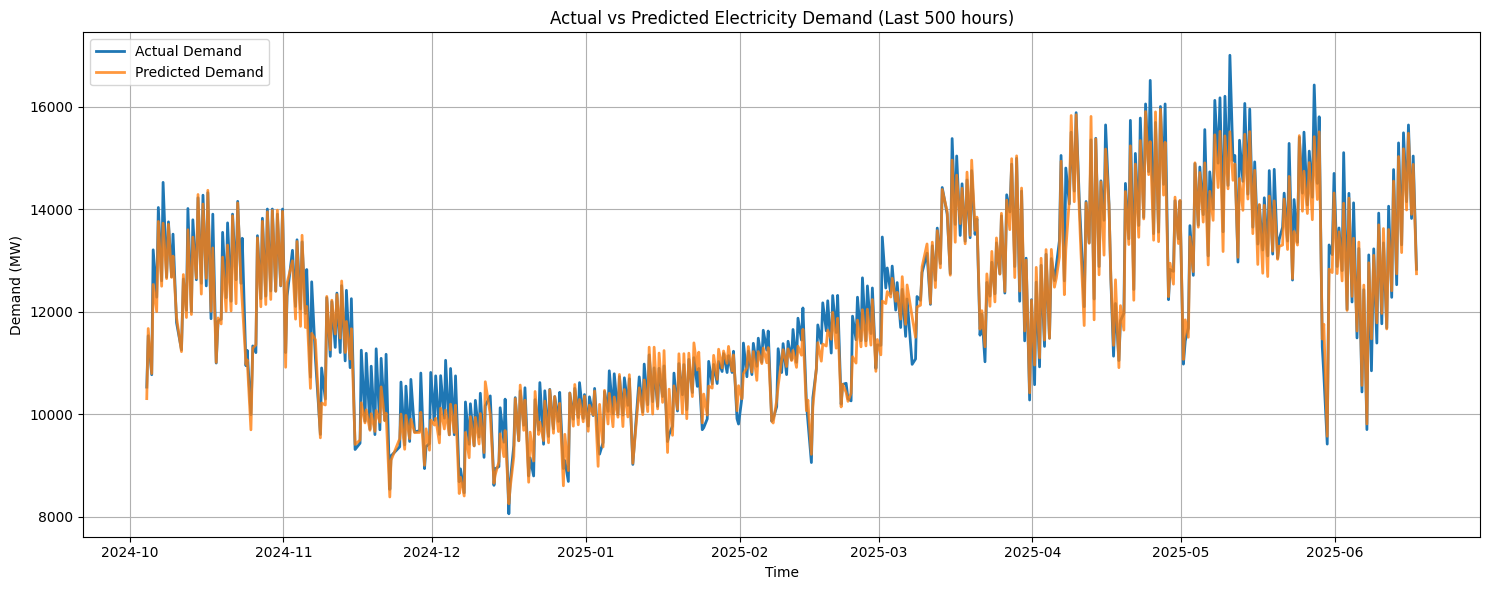

In [23]:
y_pred = best_model.predict(X_test)

plt.figure(figsize=(15, 6))
plt.plot(test['datetime'].iloc[-500:], y_test.iloc[-500:], label='Actual Demand', linewidth=2)
plt.plot(test['datetime'].iloc[-500:], y_pred[-500:], label='Predicted Demand', linewidth=2, alpha=0.8)
plt.title('Actual vs Predicted Electricity Demand (Last 500 hours)')
plt.xlabel('Time')
plt.ylabel('Demand (MW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=300)
plt.show()

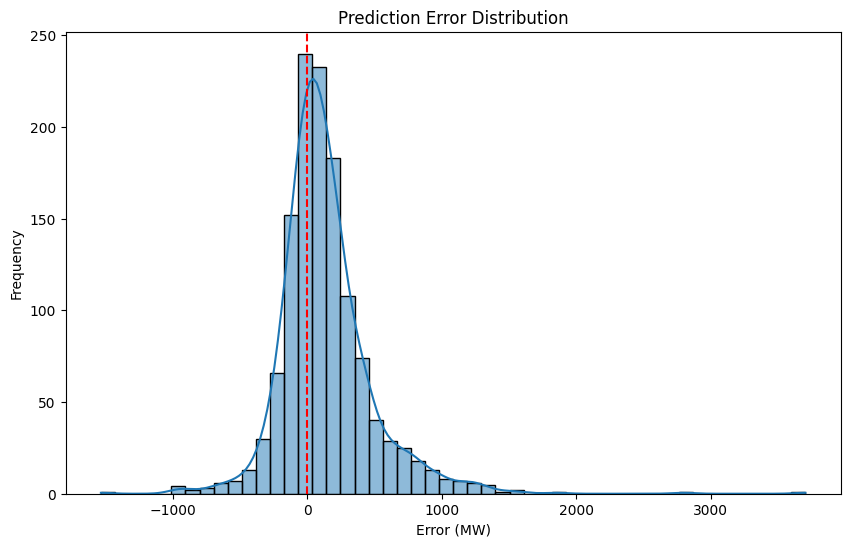

Mean Absolute Error: 244.67 MW


In [24]:
errors = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.histplot(errors, kde=True, bins=50)
plt.title('Prediction Error Distribution')
plt.xlabel('Error (MW)')
plt.ylabel('Frequency')
plt.axvline(x=0, color='r', linestyle='--')
plt.savefig('error_distribution.png', dpi=300)
plt.show()

print(f"Mean Absolute Error: {np.mean(np.abs(errors)):.2f} MW")

In [25]:
test_results = test.copy()
test_results['predicted'] = y_pred
test_results['error'] = errors

# Compare performance during peaks
peak_performance = test_results.groupby('hour').agg({
    'demand_mw': 'mean',
    'predicted': 'mean',
    'error': ['mean', 'std']
}).round(2)

print("Peak Hour Performance:")
print(peak_performance)

Peak Hour Performance:
     demand_mw     predicted   error        
          mean          mean    mean     std
hour                                        
8     10448.00  10594.059570 -146.07  261.41
9     10986.50  11403.650391 -417.15  290.47
10    12891.73  12864.419922   27.31  136.14
11    11455.44  11369.179688   86.26  258.22
17    10718.21  10184.440430  533.78  403.81
18    12293.14  12150.040039  143.10  435.42
19    13820.58  13779.740234   40.84  221.73
20    14277.78  14133.940430  143.84  332.50


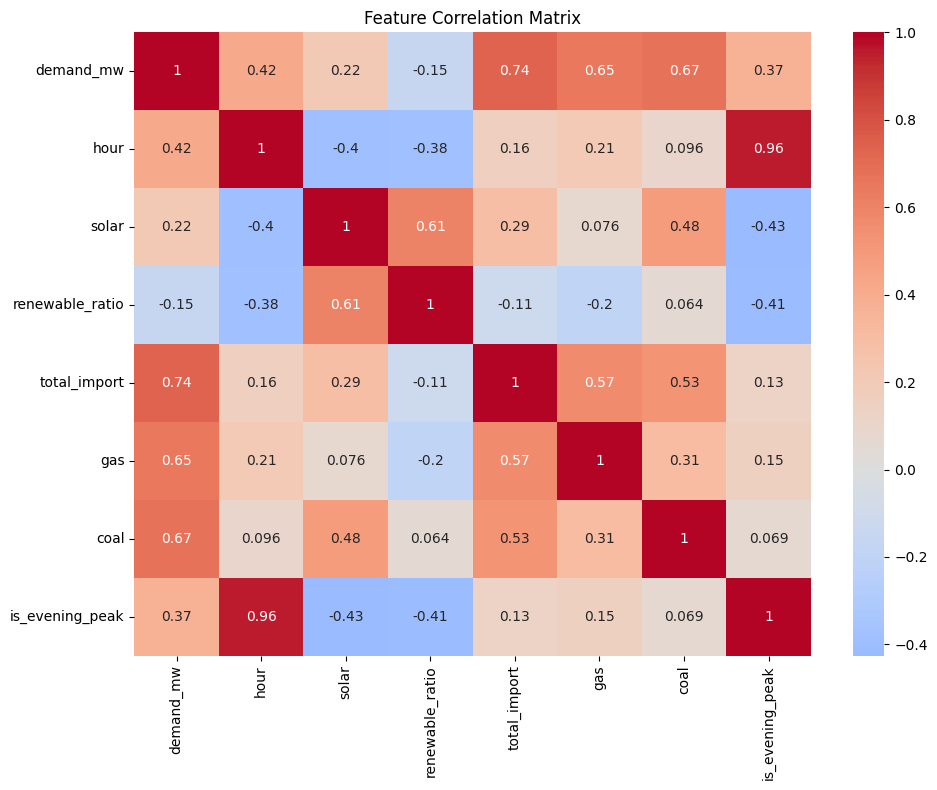

In [26]:
corr_features = ['demand_mw', 'hour', 'solar', 'renewable_ratio', 'total_import',
                 'gas', 'coal', 'is_evening_peak']

plt.figure(figsize=(10, 8))
sns.heatmap(train[corr_features].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()